# Wildfire Mapping with NASA FIRMS API

In this project, I explore recent wildfire detections in Europe using data from the NASA FIRMS API. The goal is to investigate where recent fires are located, how intense they are, and how detection confidence can be visualized on an interactive map.

## Workflow

The workflow of this project consists of a few main steps. First, recent wildfire detections are downloaded from the NASA FIRMS API. The raw data is then inspected and cleaned before the most relevant variables are analyzed. Finally, the wildfire detections are visualized on an interactive map using Folium.

In [61]:
from pathlib import Path
from io import StringIO
from geopy.geocoders import Nominatim
import time
import requests
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt


## Project folders

I use relative paths so that the notebook can be run from another computer as long as the repository structure stays the same.

In [62]:
PROJECT_ROOT = Path("..")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"


## API settings

In this step, I define the main settings for the API request. I use recent VIIRS fire detections for Europe and set the time window to seven days.

In [63]:
from config import MAP_KEY

SOURCE = "VIIRS_SNPP_NRT"
AREA = "-10,35,30,72"
DAYS = 5

RAW_FILE = RAW_DATA_DIR / f"nasa_raw_.csv"
PROCESSED_FILE = PROCESSED_DATA_DIR / f"nasa_cleaned_.csv"

SOURCE, AREA, DAYS

('VIIRS_SNPP_NRT', '-10,35,30,72', 5)

## Online and offline mode

To make the workflow more reproducible, the notebook can either download fresh wildfire detections from the NASA FIRMS API or load a previously saved local dataset.

In [64]:
USE_API = True #False

## Download wildfire data from the NASA FIRMS API

In this step, I download recent wildfire detections from the NASA FIRMS API. The API returns the data as CSV text.

I use `StringIO` because the API response is not yet a saved CSV file on my computer. `StringIO` lets pandas read this text as if it were a file. After that, I save the data in `data/raw` so that the same dataset can be used again later.

If `USE_API = False`, the notebook skips the API request and loads the saved raw CSV file instead.

In [65]:
if USE_API:

    url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{SOURCE}/{AREA}/{DAYS}"

    response = requests.get(url)

    if response.status_code == 200:

        df = pd.read_csv(StringIO(response.text))

        df.to_csv(RAW_FILE, index=False)

        print("Raw wildfire data downloaded and saved.")

    else:
        print(f"Request failed. Status code: {response.status_code}")

else:

    df = pd.read_csv(RAW_FILE)

    print("Stored raw wildfire data loaded.")

Raw wildfire data downloaded and saved.


## Inspecting the raw wildfire data

Before cleaning the dataset, I first inspect the structure of the raw wildfire detections and check which variables are available.

In [66]:
df.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,64.64674,24.42244,303.49,0.51,0.41,2026-05-15,33,N,VIIRS,n,2.0NRT,277.95,1.70,N
1,65.55943,22.21993,302.99,0.40,0.44,2026-05-15,33,N,VIIRS,n,2.0NRT,275.89,2.36,N
2,65.56007,22.21131,296.33,0.40,0.44,2026-05-15,33,N,VIIRS,n,2.0NRT,275.56,2.36,N
3,65.56287,22.23027,309.46,0.40,0.44,2026-05-15,33,N,VIIRS,n,2.0NRT,276.41,2.89,N
4,65.56349,22.22170,349.35,0.40,0.44,2026-05-15,33,N,VIIRS,n,2.0NRT,281.07,2.36,N


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1321 entries, 0 to 1320
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    1321 non-null   float64
 1   longitude   1321 non-null   float64
 2   bright_ti4  1321 non-null   float64
 3   scan        1321 non-null   float64
 4   track       1321 non-null   float64
 5   acq_date    1321 non-null   str    
 6   acq_time    1321 non-null   int64  
 7   satellite   1321 non-null   str    
 8   instrument  1321 non-null   str    
 9   confidence  1321 non-null   str    
 10  version     1321 non-null   str    
 11  bright_ti5  1321 non-null   float64
 12  frp         1321 non-null   float64
 13  daynight    1321 non-null   str    
dtypes: float64(7), int64(1), str(6)
memory usage: 175.6 KB


## Cleaning and preparing the wildfire data

Before creating maps and analyses, I clean and prepare the dataset. I keep the most relevant variables and convert the acquisition date into a proper datetime format.

In [68]:
selected_columns = [
    "latitude",
    "longitude",
    "acq_date",
    "confidence",
    "frp",
    "daynight"
]

df = df[selected_columns].copy()

df["acq_date"] = pd.to_datetime(df["acq_date"])

df.head()

,latitude,longitude,acq_date,confidence,frp,daynight
0,64.64674,24.42244,2026-05-15,n,1.70,N
1,65.55943,22.21993,2026-05-15,n,2.36,N
2,65.56007,22.21131,2026-05-15,n,2.36,N
3,65.56287,22.23027,2026-05-15,n,2.89,N
4,65.56349,22.22170,2026-05-15,n,2.36,N


## Saving the cleaned dataset

After cleaning the data, I save the processed wildfire detections as a separate CSV file. This keeps the raw API data unchanged and makes later analysis steps easier.

In [69]:
df.to_csv(PROCESSED_FILE, index=False)

print("Cleaned wildfire data saved.")

Cleaned wildfire data saved.


## Exploring the wildfire detections

Before creating the map, I explore some basic characteristics of the wildfire detections, such as the number of events, confidence levels, and fire intensity values.

In [70]:
print(f"Number of wildfire detections: {len(df)}")

print("\nConfidence levels:")
print(df["confidence"].value_counts())

print("\nTop 5 highest FRP values:")
print(df["frp"].sort_values(ascending=False).head())

Number of wildfire detections: 1321

Confidence levels:
confidence
n    1282
l      30
h       9
Name: count, dtype: int64

Top 5 highest FRP values:
234    456.25
539    123.47
232    107.77
277     90.82
272     90.82
Name: frp, dtype: float64


## Strongest wildfire detections

To better understand the most intense detections, I sort the dataset by fire radiative power and show the strongest events with their location and date.

In [71]:
top_fires = df.sort_values("frp", ascending=False).head(10)

top_fires

,latitude,longitude,acq_date,confidence,frp,daynight
234,50.13212,29.98891,2026-05-15,h,456.25,D
539,45.21706,28.85383,2026-05-16,n,123.47,D
232,50.12323,29.98574,2026-05-15,n,107.77,D
277,50.13609,29.99706,2026-05-15,h,90.82,D
272,50.12955,29.99687,2026-05-15,l,90.82,D
275,50.13433,29.99954,2026-05-15,l,70.45,D
269,50.12785,29.99088,2026-05-15,n,70.45,D
268,50.12780,29.99939,2026-05-15,n,70.45,D
276,50.13438,29.99104,2026-05-15,n,70.45,D
771,45.54865,11.96755,2026-05-17,n,31.58,D


## Countries of the strongest wildfire detections

To better understand where the strongest wildfire detections occurred, I used reverse geocoding to assign a country to the ten highest FRP values.

As of 17 May 2026, eight out of the ten strongest wildfire detections in the dataset were located in Ukraine. This raises the question of whether some of these detections could be related to the ongoing war, although the dataset itself does not provide enough information to confirm the exact cause of the fires.

In [72]:
top10 = df.nlargest(10, "frp").copy()

geolocator = Nominatim(user_agent="Country_top10_fire")

countries = []

for i, row in top10.iterrows():
    location = geolocator.reverse((row["latitude"], row["longitude"]), language="en")
    
    country = location.raw["address"].get("country", "Unknown")
    countries.append(country)
    
    time.sleep(1)

top10["country"] = countries

top10[["latitude", "longitude", "frp", "confidence", "country"]]

,latitude,longitude,frp,confidence,country
234,50.13212,29.98891,456.25,h,Ukraine
539,45.21706,28.85383,123.47,n,Romania
232,50.12323,29.98574,107.77,n,Ukraine
272,50.12955,29.99687,90.82,l,Ukraine
277,50.13609,29.99706,90.82,h,Ukraine
268,50.12780,29.99939,70.45,n,Ukraine
269,50.12785,29.99088,70.45,n,Ukraine
275,50.13433,29.99954,70.45,l,Ukraine
276,50.13438,29.99104,70.45,n,Ukraine
771,45.54865,11.96755,31.58,n,Italy


## Saving the strongest detections

I save the ten strongest wildfire detections as a separate output table. This makes it easier to use the result later in the report.

In [73]:
today = pd.Timestamp.today().strftime("%d%m%Y")

TOP_FIRES_FILE = OUTPUT_DIR / f"top_fire_detections_{today}.csv"

top10.to_csv(TOP_FIRES_FILE, index=False)

print("Top wildfire detections saved.")

Top wildfire detections saved.


## Fire radiative power distribution

To better understand the intensity of the wildfire detections, I visualize the distribution of FRP values.

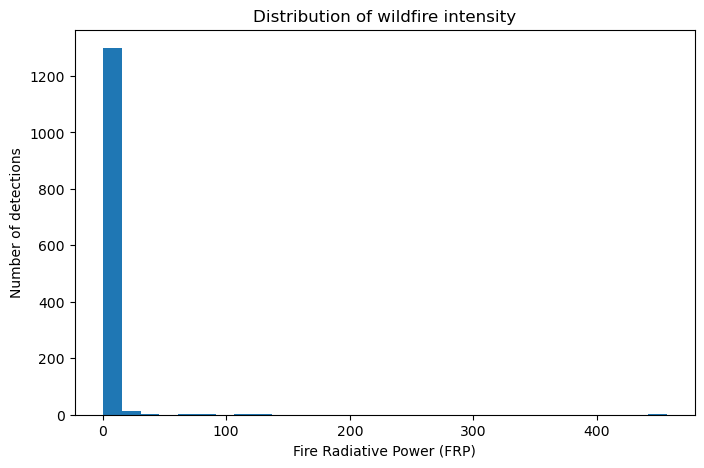

In [74]:
plt.figure(figsize=(8, 5))

plt.hist(df["frp"], bins=30)

plt.xlabel("Fire Radiative Power (FRP)")
plt.ylabel("Number of detections")
plt.title("Distribution of wildfire intensity")

plt.show()

## Creating a GeoDataFrame

To visualize the wildfire detections on a map, I convert the latitude and longitude coordinates into spatial point geometries using GeoPandas.

In [75]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

gdf.head()

,latitude,longitude,acq_date,confidence,frp,daynight,geometry
0,64.64674,24.42244,2026-05-15,n,1.70,N,POINT (24.42244 64.64674)
1,65.55943,22.21993,2026-05-15,n,2.36,N,POINT (22.21993 65.55943)
2,65.56007,22.21131,2026-05-15,n,2.36,N,POINT (22.21131 65.56007)
3,65.56287,22.23027,2026-05-15,n,2.89,N,POINT (22.23027 65.56287)
4,65.56349,22.22170,2026-05-15,n,2.36,N,POINT (22.2217 65.56349)


## Creating the interactive wildfire map

In this final visualization step, I create an interactive map with Folium. The wildfire detections are shown as circle markers. Larger markers represent stronger fires, while the popup displays additional information about each detection.

In [78]:
wildfire_map = folium.Map(
    location=[54, 15],
    zoom_start=4,
    tiles="CartoDB positron"
)

for _, row in gdf.iterrows():

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=max(row["frp"] / 10, 3),
        popup=(
            f"Date: {row['acq_date'].date()}<br>"
            f"Confidence: {row['confidence']}<br>"
            f"FRP: {row['frp']}"
        ),
        color="red",
        fill=True,
        fill_opacity=0.7
    ).add_to(wildfire_map)

wildfire_map

## Saving the interactive wildfire map

After creating the interactive wildfire map, I save it as an HTML file in the outputs folder. This makes it possible to reopen the map later in a web browser and include it in the final project results.

In [79]:
today = pd.Timestamp.today().strftime("%d%m%Y")

MAP_FILE = OUTPUT_DIR / f"wildfire_map_{today}.html"

wildfire_map.save(MAP_FILE)

print("Interactive wildfire map saved.")

Interactive wildfire map saved.
